<div align="center">

<h1> <b> MODELO DE SOMBREADO GEOMÉTRICO PARA EL CRECIMIENTO DE PELÍCULAS DELGADAS </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara <br>
Juan Palacio <br>
Sofía Moscoso <br>
Lucas Perdomo</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---

## 1. Introducción y objetivos

Este proyecto estudia qué procesos físicos determinan la morfología de una película delgada de cobre (Cu) depositada sobre vidrio por evaporación térmica en una cámara de vacío. Los mecanismos físicos se incorporan uno a uno en cuadernos independientes, de modo que el efecto de cada uno sobre la morfología pueda distinguirse.

Los cuadernos anteriores supusieron que el flujo de partículas tiene acceso a cualquier punto del sustrato, sin importar el relieve acumulado. Con incidencia oblicua, en cambio, las elevaciones de la superficie interceptan parte del flujo que iría a los sitios contiguos, un fenómeno conocido como **sombreado geométrico**. El cuaderno 4 incorporó la dispersión angular del haz y mostró que el confinamiento en los bordes de la malla acumula partículas y falsea la rugosidad global. Este quinto cuaderno sustituye ese confinamiento por **condiciones de frontera periódicas** (PBC) e implementa un trazador de rayos de línea de visión (*line-of-sight ray tracing*) acoplado a la matriz de alturas.

### Objetivos

* Desarrollar un trazador de rayos discreto acoplado a la matriz de alturas bajo condiciones de frontera toroidales.
* Verificar el mecanismo de sombreado aislándolo de la difusión térmica, y evaluar cuánto lo compensa la difusión a $T = 400$ K.
* Comparar la evolución temporal de la rugosidad RMS ($W$) con y sin sombreado, tomando el modelo de deposición aleatoria (RD) como referencia analítica.

## 2. Marco teórico y modelo físico

### 2.1 Sombreado y realimentación positiva

Con incidencia oblicua, una elevación de la superficie intercepta parte del flujo que iría a los sitios contiguos más bajos, que quedan en su sombra. La elevación recibe entonces más partículas y los valles menos, lo que refuerza la diferencia de alturas. Esta realimentación positiva es la **inestabilidad de sombra** (Karunasiri et al., 1989):

$$\text{fluctuación de altura} \longrightarrow \text{mayor captura de flujo} \longrightarrow \text{crecimiento más rápido} \longrightarrow \text{mayor sombra}.$$

La difusión superficial tiende a suavizar el relieve y compite con este mecanismo. En el modelo continuo de Karunasiri et al. (1989), con difusión suficiente la película crece compacta y plana hasta una altura crítica, y la deposición posterior la rugosa. Este cuaderno estudia cuánto aumenta la rugosidad por sombreado en el modelo discreto y en qué condiciones.

### 2.2 Trazador de rayos

Cada partícula tiene un punto de mira $(x_0, y_0)$ en el plano $z = 0$, elegido con probabilidad uniforme, y una dirección definida por los ángulos $\theta_x$ y $\theta_y$ respecto a la normal, con $\theta_x, \theta_y \sim \mathcal{N}(0, \sigma_\theta)$. Su trayectoria rectilínea pasa por el punto de mira y, a la altura $z$, está en

$$x(z) = x_0 + z \tan\theta_x, \qquad y(z) = y_0 + z \tan\theta_y.$$

La partícula se lanza desde un techo $z_{\mathrm{ini}} = h_{\max} + 5$ y desciende en pasos $\Delta z$ (`PASO_Z`). En cada altura se toma la celda redondeada de $(x(z), y(z))$, con condiciones periódicas (sección 2.3), y la partícula colisiona en el primer paso en que

$$z \leq h\big(x(z), y(z)\big).$$

Si no encuentra obstáculos, llega a $z = 0$ sobre su punto de mira. La celda de colisión es donde se incorpora la partícula, antes de la relajación térmica.

Las alturas se miden en capas y las distancias laterales en celdas, de modo que el modelo supone que el espesor de una capa equivale al tamaño de una celda: $\tan\theta$ es el desplazamiento lateral, en celdas, por cada capa de descenso.

### 2.3 Fronteras periódicas y difusión

En el cuaderno 4, el confinamiento de las partículas desviadas fuera de la malla acumuló material en los bordes y la rugosidad global dependió de la geometría por ese artefacto. Aquí las posiciones se toman módulo el tamaño de la malla,

$$x_{\mathrm{pbc}} = x \bmod N_x, \qquad y_{\mathrm{pbc}} = y \bmod N_y,$$

tanto en el trazado de rayos como en los vecinos de la difusión. Con esta condición, un desplazamiento lateral independiente no altera la distribución uniforme de los puntos de impacto, de modo que cualquier cambio de la morfología con $\sigma_\theta$ se debe al sombreado y no a los bordes.

Tras la colisión, la partícula se relaja con la regla del cuaderno 4: hasta `MAX_DIFFUSION_STEPS` saltos a vecinos de von Neumann estrictamente más bajos, cada uno con probabilidad $P(T) = \min(1, T/T_1)$, donde $T_1 = 500$ K es una temperatura de escala sin calibrar. Por último, $h(i^*, j^*) \leftarrow h(i^*, j^*) + 1$.

### 2.4 Alcance del formalismo

La superficie es una función de altura $h(i, j)$ sin voladizos ni huecos (aproximación SOS). Una partícula que choca con la pared lateral de una columna se incorpora en la parte superior de esa columna, de modo que las columnas solo crecen en vertical: el modelo no representa su ensanchamiento ni la porosidad. Además, la distribución normal de los ángulos no está acotada. Para $\sigma_\theta = 25^\circ$, cerca del $1\,\%$ de los ángulos supera $63^\circ$, donde $|\tan\theta| > 2$ y un paso $\Delta z = 0.5$ avanza más de una celda en horizontal y puede omitir columnas delgadas.

### 2.5 Referencias analíticas

Sea $M = N_x N_y$ el número de celdas y $N$ el número de eventos. Cada evento añade una capa, de modo que $\sum h = N$ y $\overline{h}_{\mathrm{teo}} = N/M$, relación exacta que expresa la conservación del número de partículas.

Sin difusión ($T = 0$) y sin dispersión angular ($\sigma_\theta = 0$), todos los rayos son verticales y el modelo se reduce a RD. Las alturas siguen entonces una distribución de Poisson de media $\lambda = \overline{h}$, la rugosidad vale $W_{\mathrm{RD}} = \sqrt{\overline{h}}$ y una realización fluctúa alrededor de ese valor con desviación típica $\sigma_W \approx W_{\mathrm{RD}}/\sqrt{2M}$ (cuaderno 1; Barabási & Stanley, 1995, cap. 4). Con $T = 0$ y $\sigma_\theta > 0$, el sombreado debería elevar $W$ por encima de $W_{\mathrm{RD}}$. Ambos límites permiten validar el código.

Con difusión no se usa una predicción analítica de $W$. La validación se apoya en la conservación de partículas, en los límites anteriores y en la comparación con la referencia sin sombreado ($\sigma_\theta = 0$).

## 3. Librerías y configuración

El cálculo numérico usa NumPy (Harris et al., 2020) y las tablas de resultados se organizan con pandas (McKinney, 2010). Los ciclos de trazado de rayos, difusión y cálculo de métricas se compilan con Numba (Lam et al., 2015) cuando la librería está instalada; si no lo está, las mismas funciones se ejecutan como Python puro, con más lentitud pero con las mismas propiedades estadísticas. SciPy (Virtanen et al., 2020) aporta la distribución de Poisson de referencia y Matplotlib (Hunter, 2007) se encarga de la visualización.

Numba mantiene un generador de números pseudoaleatorios propio, con un estado independiente del de NumPy: sembrar uno no modifica al otro (Numba, s. f.). Por ello cada simulación fija su semilla dentro de la función compilada (sección 5). Las semillas de las distintas simulaciones se derivan de una única semilla con `SeedSequence` de NumPy, de modo que cada una es independiente y reproducible por separado. Las secuencias de Numba y de NumPy no tienen por qué coincidir para una misma semilla, de manera que una realización concreta solo es reproducible dentro de un mismo modo de ejecución.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import poisson

# Numba es una dependencia opcional de aceleración. Si no está instalada, las
# funciones numéricas se ejecutan sin compilar: el resultado es estadísticamente
# equivalente, aunque más lento.
try:
    from numba import njit
    NUMBA_DISPONIBLE = True
except ImportError:
    NUMBA_DISPONIBLE = False

    def njit(*args, **kwargs):
        """ Sustituto de ``numba.njit`` que deja la función sin compilar.

        Admite tanto la forma ``@njit`` como la forma ``@njit(...)``.
        """
        if len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorador(funcion):
            return funcion

        return decorador

if not NUMBA_DISPONIBLE:
    print("Numba no está disponible: la simulación se ejecutará en Python puro (más lenta).")

# Mostrar todas las columnas de las tablas de resultados
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Estilo de las figuras. La resolución de guardado (300 dpi) es la adecuada
# para insertarlas en un informe.
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'serif',
    'figure.dpi': 120,
    'savefig.dpi': 300
})

## 4. Parámetros del sistema

Las dimensiones de la malla se dan en celdas, el número de eventos en partículas depositadas, las temperaturas en kelvin, los ángulos en grados y las alturas en capas. Con 50 000 eventos sobre $200 \times 200$ celdas, el espesor medio es de 1.25 capas: una película muy delgada, en la que todavía no se han desarrollado columnas. Los cuadernos 1 a 4 depositaron 10, 10, 2.5 y 4 capas, así que la comparación con RD se hace aquí con la referencia analítica evaluada a este espesor.

In [2]:
# Dimensiones del sustrato (número de celdas en cada dirección)
NX = 200
NY = 200

# Condición base
N_EVENTOS = 50_000          # partículas por simulación (espesor medio N_EVENTOS / (NX * NY) = 1.25 capas)
TEMPERATURE = 400           # temperatura del sustrato (K)
T_ESCALA = 500              # temperatura de escala de P(T) = min(1, T / T_ESCALA), en kelvin
MAX_DIFFUSION_STEPS = 5     # número máximo de saltos por partícula
GUARDAR_CADA = 500          # intervalo de muestreo de la evolución temporal, en eventos
SIGMA_ANGLE = 15            # dispersión angular sigma_theta, en grados
PASO_Z = 0.5                # paso vertical del trazador de rayos, en capas

# Experimento I: barrido de la dispersión angular (el primer valor debe ser 0: referencia sin sombreado)
ANGULOS_PRUEBA = [0, 2, 5, 10, 15, 25]

# Experimento II: barrido del espesor con sombreado (sigma_theta = SIGMA_FIJO_ESTUDIO) y sin él (sigma_theta = 0)
VOLUMEN_EVENTOS = [10_000, 25_000, 50_000, 75_000]
SIGMA_FIJO_ESTUDIO = 15

# Réplicas independientes por cada valor de los barridos
REPLICAS_ESTADISTICAS = 3

# Dispersiones angulares cuyas superficies se comparan visualmente
ANGULOS_COMPLEMENTARIOS = [0, 5, 12, 25]

# Tiempo mínimo, en capas depositadas, desde el que se estima el exponente de
# crecimiento efectivo. Se excluye el transitorio inicial de muy baja cobertura.
T_MIN_AJUSTE = 0.25

# Semilla única de la que se derivan las semillas de todas las simulaciones (ver sección 3)
SEMILLA = 101

if ANGULOS_PRUEBA[0] != 0:
    raise ValueError("El primer valor de ANGULOS_PRUEBA debe ser 0 (referencia sin sombreado).")

## 5. Funciones del modelo

La función `calcular_metricas_pbc` obtiene $\overline{h}$ y $W$ con dos recorridos de la malla: primero la media y después las desviaciones respecto a ella. Este esquema evita la cancelación numérica que aparece al restar $\langle h^2 \rangle - \langle h \rangle^2$ cuando la media es grande frente a la dispersión.

La función `trazador_rayos_shadowing` determina la celda de colisión de una partícula según la sección 2.2. El techo de vuelo se calcula a partir de la altura máxima $h_{\max}$, que el ciclo principal mantiene de forma incremental porque las alturas solo crecen; así se evita recorrer toda la malla en cada evento. La función `difundir_particula_pbc` aplica la relajación por descenso con fronteras periódicas, y recorre la vecindad dos veces, primero para contar los vecinos más bajos y luego para localizar el elegido, en lugar de construir un arreglo de candidatos en cada salto.

La función `ejecutar_simulacion_shadowing_historial` implementa el ciclo Monte Carlo y registra las métricas cada `guardar_cada` eventos; `ejecutar_simulacion_shadowing` la invoca sin conservar el historial. El ciclo es estrictamente secuencial: cada rayo se traza sobre el relieve que dejaron los anteriores y todos modifican la misma matriz de alturas, por lo que una simulación no se paraleliza. Las réplicas son independientes entre sí y se ejecutan en serie.

Por último, `resumir_superficie` calcula con NumPy, sobre una superficie terminada, las métricas que se tabulan.

In [3]:
@njit
def calcular_metricas_pbc(superficie, nx, ny):
    """Calcula el espesor medio y la rugosidad RMS de una superficie.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Altura de cada celda, en capas.
    nx, ny : int
        Número de celdas en cada dirección.

    Devuelve
    --------
    espesor : float
        Altura media, en capas.
    rugosidad : float
        Desviación estándar poblacional de las alturas (divisor nx * ny), en capas.
    """
    # Se calcula primero la media y después las desviaciones respecto a ella
    # (dos pasadas). Restar <h^2> - <h>^2 en una sola pasada perdería precisión
    # cuando la media es grande frente a la dispersión.
    suma_alturas = 0.0
    for i in range(nx):
        for j in range(ny):
            suma_alturas += superficie[i, j]
    espesor = suma_alturas / (nx * ny)

    suma_varianza = 0.0
    for i in range(nx):
        for j in range(ny):
            diferencia = superficie[i, j] - espesor
            suma_varianza += diferencia * diferencia
    rugosidad = np.sqrt(suma_varianza / (nx * ny))

    return espesor, rugosidad

In [4]:
@njit
def trazador_rayos_shadowing(x_target, y_target, nx, ny, superficie, sigma_ang, max_h_actual, paso_z):
    """Determina la celda de colisión de una partícula por trazado de rayos de línea de visión.

    Los ángulos de emisión theta_x y theta_y se sortean de una distribución normal
    de media cero y desviación sigma_ang (en grados). La partícula desciende desde
    un techo situado 5 capas por encima de la altura máxima, en pasos de paso_z, y
    colisiona en el primer paso en que su altura z no supera la de la celda que
    sobrevuela. Las posiciones laterales son periódicas.

    Parámetros
    ----------
    x_target, y_target : int
        Punto de mira en el plano z = 0.
    nx, ny : int
        Número de celdas en cada dirección.
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    sigma_ang : float
        Desviación estándar de los ángulos de emisión, en grados.
    max_h_actual : int
        Altura máxima actual de la superficie, en capas.
    paso_z : float
        Paso vertical del trazado, en capas.

    Devuelve
    --------
    cx, cy : int
        Índices de la celda de colisión.
    """
    # Dirección del flujo de vapor (en grados) y pendientes laterales por capa de descenso
    theta_x = np.random.normal(0.0, sigma_ang)
    theta_y = np.random.normal(0.0, sigma_ang)
    tan_x = np.tan(theta_x * np.pi / 180.0)
    tan_y = np.tan(theta_y * np.pi / 180.0)

    # Techo de vuelo: por encima de la altura máxima ningún rayo puede colisionar.
    z = float(max_h_actual) + 5.0

    # Si el rayo no encuentra obstáculos, llega a z = 0 sobre su punto de mira.
    cx = x_target
    cy = y_target

    while z >= 0.0:
        # Posición lateral a la altura z, redondeada a la celda más próxima
        val_x = int(np.round(x_target + z * tan_x))
        val_y = int(np.round(y_target + z * tan_y))

        # Condiciones de frontera periódicas. El resto es no negativo en Python y en
        # Numba; el ajuste solo actúa como salvaguarda.
        idx_x = val_x % nx
        idx_y = val_y % ny
        if idx_x < 0:
            idx_x += nx
        if idx_y < 0:
            idx_y += ny

        # Criterio de interceptación (sombreado)
        if z <= superficie[idx_x, idx_y]:
            cx = idx_x
            cy = idx_y
            break

        z -= paso_z

    return cx, cy

In [5]:
@njit
def difundir_particula_pbc(superficie, x, y, nx, ny, temp, t_escala, max_pasos):
    """Aplica la difusión de corto alcance por descenso con fronteras periódicas.

    En cada paso, la partícula salta con probabilidad P = min(1, temp / t_escala)
    a uno de sus vecinos de von Neumann estrictamente más bajos, elegido con igual
    probabilidad. Se detiene si no hay vecinos más bajos, si el salto falla o si
    alcanza max_pasos saltos.

    Parámetros
    ----------
    superficie : ndarray de enteros, forma (nx, ny)
        Alturas actuales, en capas. La función no las modifica.
    x, y : int
        Celda de colisión.
    nx, ny : int
        Número de celdas en cada dirección.
    temp : float
        Temperatura del sustrato, en kelvin.
    t_escala : float
        Temperatura de escala de la probabilidad de salto, en kelvin.
    max_pasos : int
        Número máximo de saltos.

    Devuelve
    --------
    curr_x, curr_y : int
        Índices de la celda que recibe la partícula.
    """
    curr_x = x
    curr_y = y

    # Desplazamientos de von Neumann: izquierda, derecha, abajo, arriba
    dx = (-1, 1, 0, 0)
    dy = (0, 0, -1, 1)

    # Probabilidad de salto según la temperatura
    prob_difusion = temp / t_escala
    if prob_difusion > 1.0:
        prob_difusion = 1.0

    for _ in range(max_pasos):
        curr_h = superficie[curr_x, curr_y]

        # Primer recorrido: número de vecinos estrictamente más bajos, con fronteras periódicas.
        conteo_validos = 0
        for i in range(4):
            nx_c = (curr_x + dx[i]) % nx
            ny_c = (curr_y + dy[i]) % ny
            if nx_c < 0:
                nx_c += nx
            if ny_c < 0:
                ny_c += ny
            if superficie[nx_c, ny_c] < curr_h:
                conteo_validos += 1

        # Sin microvalles en la vecindad, la partícula se deposita.
        if conteo_validos == 0:
            break

        # Intento de salto. Un segundo recorrido localiza al vecino elegido sin
        # crear arreglos temporales en cada paso.
        if np.random.random() < prob_difusion:
            idx = np.random.randint(0, conteo_validos)
            next_x = curr_x
            next_y = curr_y
            contador = 0
            for i in range(4):
                nx_c = (curr_x + dx[i]) % nx
                ny_c = (curr_y + dy[i]) % ny
                if nx_c < 0:
                    nx_c += nx
                if ny_c < 0:
                    ny_c += ny
                if superficie[nx_c, ny_c] < curr_h:
                    if contador == idx:
                        next_x = nx_c
                        next_y = ny_c
                        break
                    contador += 1
            curr_x = next_x
            curr_y = next_y
        else:
            break

    return curr_x, curr_y

In [6]:
@njit
def ejecutar_simulacion_shadowing_historial(nx, ny, n_eventos, temp, t_escala, max_pasos,
                                            sigma_ang, paso_z, guardar_cada, semilla):
    """Ejecuta la simulación con sombreado geométrico y registra la evolución temporal.

    Cada evento elige un punto de mira uniforme, traza el rayo hasta su celda de
    colisión (ver ``trazador_rayos_shadowing``), relaja la partícula
    (ver ``difundir_particula_pbc``) y la deposita.

    Parámetros
    ----------
    nx, ny : int
        Número de celdas en cada dirección.
    n_eventos : int
        Número total de eventos, igual al número de partículas depositadas.
    temp, t_escala : float
        Temperatura del sustrato y temperatura de escala de la probabilidad de salto, en kelvin.
    max_pasos : int
        Número máximo de saltos por partícula.
    sigma_ang : float
        Desviación estándar de los ángulos de emisión, en grados.
    paso_z : float
        Paso vertical del trazador de rayos, en capas.
    guardar_cada : int
        Intervalo de muestreo, en eventos, de las métricas temporales.
    semilla : int
        Semilla del generador pseudoaleatorio.

    Devuelve
    --------
    superficie : ndarray int32, forma (nx, ny)
        Alturas finales, en capas.
    hist_eventos : ndarray int32
        Número de eventos transcurridos en cada muestreo.
    hist_espesor, hist_rugosidad : ndarray float64
        Espesor medio y rugosidad RMS, en capas, en cada muestreo.
    """
    if nx <= 0 or ny <= 0:
        raise ValueError("nx y ny deben ser positivos.")
    if guardar_cada <= 0 or guardar_cada > n_eventos:
        raise ValueError("Se requiere 0 < guardar_cada <= n_eventos.")
    if temp < 0 or t_escala <= 0 or max_pasos < 0:
        raise ValueError("Se requiere temp >= 0, t_escala > 0 y max_pasos >= 0.")
    if sigma_ang < 0 or paso_z <= 0:
        raise ValueError("Se requiere sigma_ang >= 0 y paso_z > 0.")

    # En Numba, np.random.seed solo actúa sobre el generador de Numba si se
    # llama dentro de una función compilada; por eso la semilla se fija aquí.
    np.random.seed(semilla)

    superficie = np.zeros((nx, ny), dtype=np.int32)

    # Arreglos de tamaño fijo para el historial: evitan crecer listas dentro
    # del ciclo compilado.
    tamano_hist = n_eventos // guardar_cada
    hist_eventos = np.zeros(tamano_hist, dtype=np.int32)
    hist_espesor = np.zeros(tamano_hist, dtype=np.float64)
    hist_rugosidad = np.zeros(tamano_hist, dtype=np.float64)

    idx_hist = 0
    max_h_actual = 0
    for evento in range(1, n_eventos + 1):
        # Punto de mira, equiprobable e independiente de la altura actual.
        x_i = np.random.randint(0, nx)
        y_i = np.random.randint(0, ny)

        # Trazado balístico con sombreado y relajación térmica. Ambos dependen del
        # relieve actual, por lo que los eventos deben procesarse en orden.
        x_col, y_col = trazador_rayos_shadowing(x_i, y_i, nx, ny, superficie, sigma_ang, max_h_actual, paso_z)
        x_f, y_f = difundir_particula_pbc(superficie, x_col, y_col, nx, ny, temp, t_escala, max_pasos)
        superficie[x_f, y_f] += 1

        # Las alturas solo crecen: basta comparar con la celda que acaba de recibir la partícula.
        if superficie[x_f, y_f] > max_h_actual:
            max_h_actual = superficie[x_f, y_f]

        # Las métricas se evalúan sobre el estado acumulado de la superficie.
        if evento % guardar_cada == 0:
            esp, rug = calcular_metricas_pbc(superficie, nx, ny)
            hist_eventos[idx_hist] = evento
            hist_espesor[idx_hist] = esp
            hist_rugosidad[idx_hist] = rug
            idx_hist += 1

    return superficie, hist_eventos, hist_espesor, hist_rugosidad


@njit
def ejecutar_simulacion_shadowing(nx, ny, n_eventos, temp, t_escala, max_pasos, sigma_ang, paso_z, semilla):
    """Ejecuta la simulación con sombreado geométrico y devuelve solo la superficie final.

    Equivale a ``ejecutar_simulacion_shadowing_historial`` con una única muestra
    temporal al final; los parámetros son los mismos, salvo ``guardar_cada``.
    """
    superficie, _, _, _ = ejecutar_simulacion_shadowing_historial(
        nx, ny, n_eventos, temp, t_escala, max_pasos, sigma_ang, paso_z, n_eventos, semilla
    )
    return superficie

In [7]:
def resumir_superficie(superficie):
    """Resume una superficie terminada.

    Devuelve un diccionario con el espesor medio y la rugosidad RMS (en capas), las
    alturas máxima y mínima y el porcentaje de celdas sin cubrir (altura cero).
    """
    return {
        "espesor": superficie.mean(),
        "rugosidad": superficie.std(),
        "maximo": superficie.max(),
        "minimo": superficie.min(),
        "vacias": 100 * np.mean(superficie == 0),
    }

## 6. Condición base y validación

Se ejecuta la condición base ($\sigma_\theta$ = `SIGMA_ANGLE`, $T$ = `TEMPERATURE`) con historial temporal, junto con la misma simulación sin sombreado ($\sigma_\theta = 0$) como referencia. En cada simulación se verifica que $\sum h = N$. El exponente de crecimiento efectivo $\beta_{\mathrm{ef}}$ es la pendiente de $\ln W$ frente a $\ln t$ para $t \geq$ `T_MIN_AJUSTE`; en RD vale $1/2$.

Después se valida el modelo sin difusión ($T = 0$ K), promediando `REPLICAS_ESTADISTICAS` réplicas. Con $\sigma_\theta = 0$ la rugosidad debe coincidir con $W_{\mathrm{RD}} = \sqrt{\overline{h}}$, lo que se juzga con

$$z = \frac{\overline{W}_{\mathrm{sim}} - W_{\mathrm{RD}}}{\sigma_W/\sqrt{N_{\mathrm{réplicas}}}},$$

y se considera compatible cuando $|z| \leq 3$. Con $\sigma_\theta > 0$, el sombreado debe elevar $W$ por encima de RD.

In [8]:
n_celdas = NX * NY
espesor_teo = N_EVENTOS / n_celdas
rugosidad_rd = np.sqrt(espesor_teo)                          # RD: W = sqrt(h)
celdas_vacias_rd = 100 * poisson.pmf(0, espesor_teo)         # % de celdas con h = 0 esperado en RD

# Semillas independientes y reproducibles derivadas de SEMILLA.
secuencias = np.random.SeedSequence(SEMILLA).spawn(6)
semilla_base = int(secuencias[0].generate_state(1)[0])
semilla_ref0 = int(secuencias[1].generate_state(1)[0])
SIGMAS_VALIDACION = (0, SIGMA_ANGLE, max(ANGULOS_PRUEBA))
semillas_validacion = secuencias[2].generate_state(len(SIGMAS_VALIDACION) * REPLICAS_ESTADISTICAS)
semillas_angulos = [s.generate_state(REPLICAS_ESTADISTICAS) for s in secuencias[3].spawn(len(ANGULOS_PRUEBA))]
semillas_volumenes = [s.generate_state(2 * REPLICAS_ESTADISTICAS) for s in secuencias[4].spawn(len(VOLUMEN_EVENTOS))]
semillas_comparativas = secuencias[5].generate_state(len(ANGULOS_COMPLEMENTARIOS))


def simular_y_resumir(temp, sigma, n_eventos, semilla):
    """Simula una réplica, verifica la conservación de partículas y devuelve su resumen y su superficie."""
    superficie = ejecutar_simulacion_shadowing(
        NX, NY, n_eventos, temp, T_ESCALA, MAX_DIFFUSION_STEPS, sigma, PASO_Z, int(semilla)
    )
    # Cada evento añade exactamente una capa, aunque la partícula se relocalice: si la
    # suma no coincide con n_eventos, el resultado es incorrecto aunque no se lance
    # ninguna excepción.
    if superficie.sum() != n_eventos:
        raise RuntimeError(f"La suma de alturas no coincide con n_eventos (T = {temp} K, sigma = {sigma}).")
    return resumir_superficie(superficie), superficie


def exponente_efectivo(eventos, rugosidad):
    """Pendiente de ln W frente a ln t (t en capas) para t >= T_MIN_AJUSTE."""
    t_capas = eventos / n_celdas
    tramo = t_capas >= T_MIN_AJUSTE
    if np.count_nonzero(tramo) < 3:
        return np.nan      # muy pocas muestras en el tramo: el ajuste no es fiable
    return np.polyfit(np.log(t_capas[tramo]), np.log(rugosidad[tramo]), 1)[0]


print("Iniciando la simulación con sombreado geométrico y PBC...")
superficie_base, hist_ev, hist_esp, hist_rug = ejecutar_simulacion_shadowing_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, T_ESCALA, MAX_DIFFUSION_STEPS,
    SIGMA_ANGLE, PASO_Z, GUARDAR_CADA, semilla_base
)
print("Iniciando la simulación de referencia sin sombreado...")
superficie_sin, _, _, hist_rug_sin = ejecutar_simulacion_shadowing_historial(
    NX, NY, N_EVENTOS, TEMPERATURE, T_ESCALA, MAX_DIFFUSION_STEPS,
    0, PASO_Z, GUARDAR_CADA, semilla_ref0
)
print("Simulaciones finalizadas.")

for superficie in (superficie_base, superficie_sin):
    if superficie.sum() != N_EVENTOS:
        raise RuntimeError("La suma de alturas no coincide con el número de partículas depositadas.")
resumen_base = resumir_superficie(superficie_base)
resumen_sin = resumir_superficie(superficie_sin)
beta_base = exponente_efectivo(hist_ev, hist_rug)
beta_sin = exponente_efectivo(hist_ev, hist_rug_sin)

Iniciando la simulación con sombreado geométrico y PBC...
Iniciando la simulación de referencia sin sombreado...
Simulaciones finalizadas.


In [9]:
ANCHO = 66


def fila(etiqueta, valor):
    print(f"{etiqueta:<35}: {valor}")


print("=" * ANCHO)
print("MÉTRICAS DE LA PELÍCULA CON SOMBREADO (BASE)".center(ANCHO))
print("=" * ANCHO)
fila("Sustrato (toroidal)", f"{NX} x {NY} celdas")
fila("Partículas depositadas", N_EVENTOS)
fila("Altura máxima alcanzada", f"{resumen_base['maximo']} capas")
fila("Altura mínima alcanzada", f"{resumen_base['minimo']} capas")
print("-" * ANCHO)
fila("Espesor medio simulado", f"{resumen_base['espesor']:.4f} capas")
fila("Espesor medio teórico", f"{espesor_teo:.4f} capas")
print("-" * ANCHO)
fila(f"Rugosidad RMS (sigma = {SIGMA_ANGLE}°)", f"{resumen_base['rugosidad']:.4f} capas")
fila("Rugosidad RMS (sigma = 0°)", f"{resumen_sin['rugosidad']:.4f} capas")
fila("Rugosidad RMS de referencia (RD)", f"{rugosidad_rd:.4f} capas")
fila("Cociente con / sin sombreado", f"{resumen_base['rugosidad'] / resumen_sin['rugosidad']:.3f}")
fila(f"Exponente efectivo (sigma = {SIGMA_ANGLE}°)", f"{beta_base:.3f}  (RD: 0.5)")
fila("Exponente efectivo (sigma = 0°)", f"{beta_sin:.3f}  (RD: 0.5)")
print("-" * ANCHO)
fila(f"Celdas vacías (sigma = {SIGMA_ANGLE}°)", f"{resumen_base['vacias']:.2f} %")
fila("Celdas vacías (sigma = 0°)", f"{resumen_sin['vacias']:.2f} %")
fila("Celdas vacías (RD, teoría)", f"{celdas_vacias_rd:.2f} %")
print("=" * ANCHO)

           MÉTRICAS DE LA PELÍCULA CON SOMBREADO (BASE)           
Sustrato (toroidal)                : 200 x 200 celdas
Partículas depositadas             : 50000
Altura máxima alcanzada            : 7 capas
Altura mínima alcanzada            : 0 capas
------------------------------------------------------------------
Espesor medio simulado             : 1.2500 capas
Espesor medio teórico              : 1.2500 capas
------------------------------------------------------------------
Rugosidad RMS (sigma = 15°)        : 0.6509 capas
Rugosidad RMS (sigma = 0°)         : 0.6234 capas
Rugosidad RMS de referencia (RD)   : 1.1180 capas
Cociente con / sin sombreado       : 1.044
Exponente efectivo (sigma = 15°)   : 0.202  (RD: 0.5)
Exponente efectivo (sigma = 0°)    : 0.176  (RD: 0.5)
------------------------------------------------------------------
Celdas vacías (sigma = 15°)        : 8.33 %
Celdas vacías (sigma = 0°)         : 7.84 %
Celdas vacías (RD, teoría)         : 28.65 %


In [10]:
# Validación sin difusión (T = 0 K): sigma = 0 debe coincidir con RD y sigma > 0 debe elevar W por encima de RD
sigma_rd = rugosidad_rd / np.sqrt(2 * n_celdas)               # fluctuación de W en una realización
error_estandar = sigma_rd / np.sqrt(REPLICAS_ESTADISTICAS)    # fluctuación de la media de las réplicas

print("=" * ANCHO)
print("VALIDACIÓN SIN DIFUSIÓN (T = 0 K)".center(ANCHO))
print("=" * ANCHO)
fila("Rugosidad RD teórica (sqrt(h))", f"{rugosidad_rd:.4f} capas")
fila("Fluctuación esperada de la media", f"{error_estandar:.4f} capas")
print("-" * ANCHO)

rug_medias = []
for k, sigma in enumerate(SIGMAS_VALIDACION):
    semillas = semillas_validacion[k * REPLICAS_ESTADISTICAS:(k + 1) * REPLICAS_ESTADISTICAS]
    resumenes = [simular_y_resumir(0, sigma, N_EVENTOS, s)[0] for s in semillas]
    rug = np.mean([r["rugosidad"] for r in resumenes])
    vac = np.mean([r["vacias"] for r in resumenes])
    rug_medias.append(rug)
    fila(f"sigma = {sigma}°: W (media)", f"{rug:.4f} capas")
    fila(f"sigma = {sigma}°: W / W(RD)", f"{rug / rugosidad_rd:.3f}")
    fila(f"sigma = {sigma}°: celdas vacías", f"{vac:.2f} %")
z_rd = (rug_medias[0] - rugosidad_rd) / error_estandar
print("-" * ANCHO)
fila("Desviación z (sigma = 0°)", f"{z_rd:+.2f}")
print("=" * ANCHO)

if abs(z_rd) <= 3:
    print("A sigma = 0 la rugosidad es compatible con RD (|z| <= 3).")
else:
    print("A sigma = 0 la rugosidad se aparta de RD (|z| > 3): revisar el generador y el algoritmo.")
if all(w > rugosidad_rd + 3 * error_estandar for w in rug_medias[1:]):
    print("Con sigma > 0, el sombreado eleva la rugosidad por encima de RD, como se espera.")
else:
    print("Con sigma > 0, la rugosidad no supera a RD: el sombreado no actúa como se espera.")

                VALIDACIÓN SIN DIFUSIÓN (T = 0 K)                 
Rugosidad RD teórica (sqrt(h))     : 1.1180 capas
Fluctuación esperada de la media   : 0.0023 capas
------------------------------------------------------------------
sigma = 0°: W (media)              : 1.1188 capas
sigma = 0°: W / W(RD)              : 1.001
sigma = 0°: celdas vacías          : 28.68 %
sigma = 15°: W (media)             : 1.4023 capas
sigma = 15°: W / W(RD)             : 1.254
sigma = 15°: celdas vacías         : 35.00 %
sigma = 25°: W (media)             : 1.7163 capas
sigma = 25°: W / W(RD)             : 1.535
sigma = 25°: celdas vacías         : 43.00 %
------------------------------------------------------------------
Desviación z (sigma = 0°)          : +0.35
A sigma = 0 la rugosidad es compatible con RD (|z| <= 3).
Con sigma > 0, el sombreado eleva la rugosidad por encima de RD, como se espera.


## 7. Experimentos computacionales

El experimento I barre la dispersión angular $\sigma_\theta$ a espesor fijo. El experimento II barre el espesor con $\sigma_\theta$ = `SIGMA_FIJO_ESTUDIO` y, como control, con $\sigma_\theta = 0$, para separar el crecimiento de $W$ con el espesor que ocurre sin sombreado del que este añade. Cada valor se simula con `REPLICAS_ESTADISTICAS` réplicas independientes a la temperatura `TEMPERATURE`. Las tablas resumen la media y la desviación estándar muestral (ddof = 1) entre réplicas. Después se generan las superficies individuales que se comparan visualmente en la sección 8.

In [11]:
# Experimento I: barrido de la dispersión angular
resultados_angulos = []

for sigma, semillas in zip(ANGULOS_PRUEBA, semillas_angulos):
    print(f"Simulando réplicas para dispersión angular: {sigma}°...")
    resumenes = [simular_y_resumir(TEMPERATURE, sigma, N_EVENTOS, s)[0] for s in semillas]
    col = lambda clave: np.array([r[clave] for r in resumenes])

    resultados_angulos.append({
        "Sigma (°)": sigma,
        "Espesor medio (capas)": col("espesor").mean(),
        "Rugosidad media (capas)": col("rugosidad").mean(),
        "Desv. rugosidad": col("rugosidad").std(ddof=1),
        "Altura máxima media": col("maximo").mean(),
        "Desv. altura máxima": col("maximo").std(ddof=1),
        "Altura mínima media": col("minimo").mean(),
        "Celdas vacías (%)": col("vacias").mean(),
    })

df_angulos = pd.DataFrame(resultados_angulos)
# El primer valor de ANGULOS_PRUEBA es 0: su rugosidad es la referencia sin sombreado
df_angulos.insert(4, "W / W(sigma = 0)", df_angulos["Rugosidad media (capas)"] / df_angulos["Rugosidad media (capas)"].iloc[0])
# Tabla resumen del experimento I
df_angulos.round(3)

Simulando réplicas para dispersión angular: 0°...
Simulando réplicas para dispersión angular: 2°...
Simulando réplicas para dispersión angular: 5°...
Simulando réplicas para dispersión angular: 10°...
Simulando réplicas para dispersión angular: 15°...
Simulando réplicas para dispersión angular: 25°...


,Sigma (°),Espesor medio (capas),Rugosidad media (capas),Desv. rugosidad,W / W(sigma = 0),Altura máxima media,Desv. altura máxima,Altura mínima media,Celdas vacías (%)
0,0,1.25,0.628,0.001,1.000,5.000,0.000,0.0,7.967
1,2,1.25,0.627,0.003,0.999,4.333,0.577,0.0,7.983
2,5,1.25,0.627,0.002,0.998,5.000,0.000,0.0,7.868
3,10,1.25,0.637,0.002,1.015,5.667,1.155,0.0,8.078
4,15,1.25,0.654,0.002,1.042,6.000,0.000,0.0,8.453
5,25,1.25,0.684,0.003,1.090,6.667,1.155,0.0,9.390


In [12]:
# Experimento II: barrido del espesor, con sombreado y sin él
resultados_espesores = []

for eventos, semillas in zip(VOLUMEN_EVENTOS, semillas_volumenes):
    print(f"Evaluando la rugosidad para {eventos} eventos...")
    rug = {}
    for k, sigma in enumerate((0, SIGMA_FIJO_ESTUDIO)):
        semillas_sigma = semillas[k * REPLICAS_ESTADISTICAS:(k + 1) * REPLICAS_ESTADISTICAS]
        rug[sigma] = np.array([
            simular_y_resumir(TEMPERATURE, sigma, eventos, s)[0]["rugosidad"] for s in semillas_sigma
        ])

    espesor_nominal = eventos / n_celdas
    resultados_espesores.append({
        "Eventos": eventos,
        "Espesor nominal (capas)": espesor_nominal,
        "W sin sombreado": rug[0].mean(),
        "Desv. sin sombreado": rug[0].std(ddof=1),
        "W con sombreado": rug[SIGMA_FIJO_ESTUDIO].mean(),
        "Desv. con sombreado": rug[SIGMA_FIJO_ESTUDIO].std(ddof=1),
        "Cociente con / sin": rug[SIGMA_FIJO_ESTUDIO].mean() / rug[0].mean(),
        "W de RD (sqrt(h))": np.sqrt(espesor_nominal),
    })

df_espesores = pd.DataFrame(resultados_espesores)
# Tabla resumen del experimento II
df_espesores.round(3)

Evaluando la rugosidad para 10000 eventos...
Evaluando la rugosidad para 25000 eventos...
Evaluando la rugosidad para 50000 eventos...
Evaluando la rugosidad para 75000 eventos...


,Eventos,Espesor nominal (capas),W sin sombreado,Desv. sin sombreado,W con sombreado,Desv. con sombreado,Cociente con / sin,W de RD (sqrt(h))
0,10000,0.250,0.448,0.000,0.450,0.002,1.006,0.500
1,25000,0.625,0.578,0.001,0.584,0.002,1.011,0.791
2,50000,1.250,0.628,0.002,0.651,0.005,1.037,1.118
3,75000,1.875,0.659,0.002,0.705,0.002,1.069,1.369


In [13]:
# Superficies individuales para la comparación morfológica multiángulo
superficies_comparativas = {}
for sigma, semilla in zip(ANGULOS_COMPLEMENTARIOS, semillas_comparativas):
    _, superficies_comparativas[sigma] = simular_y_resumir(TEMPERATURE, sigma, N_EVENTOS, semilla)
print("Superficies comparativas generadas para sigma =", ANGULOS_COMPLEMENTARIOS)

Superficies comparativas generadas para sigma = [0, 5, 12, 25]


## 8. Visualización de resultados

Las cuatro primeras figuras muestran las firmas morfológicas de la condición base. Las dos siguientes presentan las tendencias de la rugosidad con la dispersión angular y con el espesor, con barras de error que indican la desviación estándar entre réplicas. Las tres últimas comparan superficies a distintas dispersiones angulares. Además de mostrarse en el cuaderno, cada figura se guarda como archivo PNG en el directorio de trabajo.

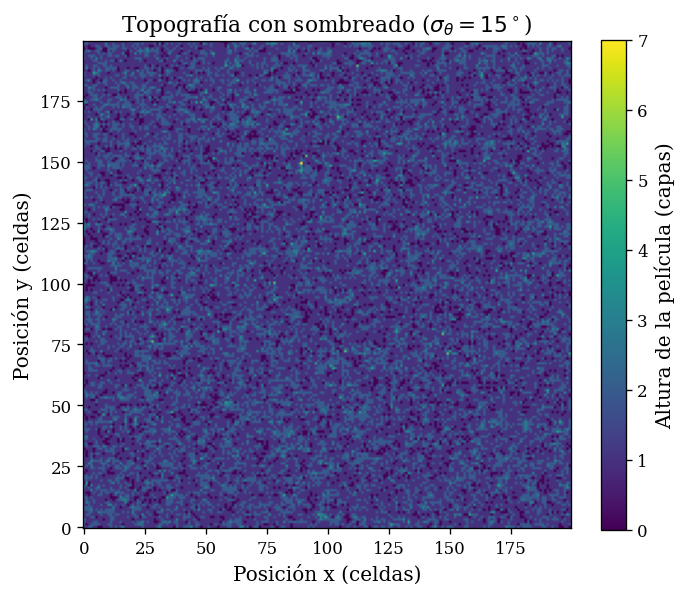

In [14]:
# Topografía de la condición base
fig, ax = plt.subplots(figsize=(6, 5))
# Se transpone la matriz para que el eje horizontal sea x (primer índice de la
# malla) y el vertical sea y (segundo índice).
imagen = ax.imshow(superficie_base.T, origin="lower", cmap="viridis")
fig.colorbar(imagen, ax=ax, label="Altura de la película (capas)")
ax.set_xlabel("Posición x (celdas)")
ax.set_ylabel("Posición y (celdas)")
ax.set_title(rf"Topografía con sombreado ($\sigma_\theta = {SIGMA_ANGLE}^\circ$)")
fig.tight_layout()
fig.savefig("shadowing_topografia_2d.png", bbox_inches="tight")
plt.show()

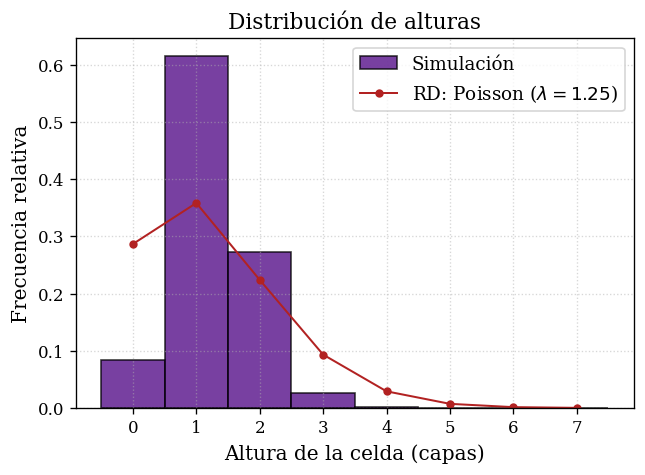

In [15]:
# Distribución de alturas de la condición base frente a la estadística de Poisson del modelo RD
altura_sup = max(int(resumen_base["maximo"]), int(np.ceil(espesor_teo + 5 * rugosidad_rd)))
bordes = np.arange(0, altura_sup + 2) - 0.5          # un intervalo de anchura unidad por altura entera
alturas_enteras = np.arange(0, altura_sup + 1)

fig, ax = plt.subplots(figsize=(6, 4))
# Con density=True e intervalos de anchura unidad, la altura de cada barra es la
# frecuencia relativa de esa altura.
ax.hist(
    superficie_base.ravel(), bins=bordes, density=True, color="indigo",
    edgecolor="black", alpha=0.75, label="Simulación",
)
ax.plot(
    alturas_enteras, poisson.pmf(alturas_enteras, espesor_teo), "o-", color="firebrick",
    markersize=4, linewidth=1.2, label=rf"RD: Poisson ($\lambda = {espesor_teo:g}$)",
)
ax.set_xlabel("Altura de la celda (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribución de alturas")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend()
fig.savefig("shadowing_histograma.png", bbox_inches="tight")
plt.show()

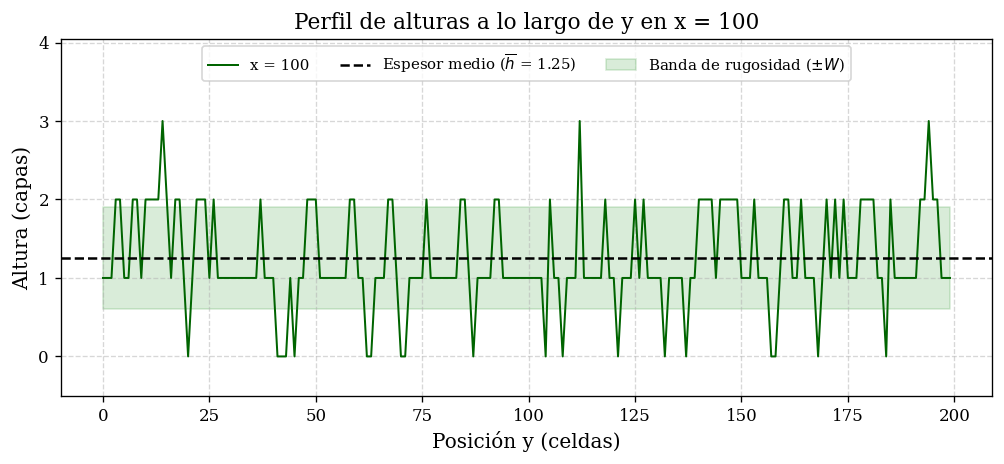

In [16]:
# Perfil unidimensional de la condición base: alturas a lo largo de y en la coordenada x central
x_central = NX // 2
perfil = superficie_base[x_central, :]
espesor_base = resumen_base["espesor"]
rugosidad_base = resumen_base["rugosidad"]

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(perfil, color="darkgreen", linewidth=1.2, label=f"x = {x_central}")
ax.axhline(
    espesor_base, color="black", linestyle="--",
    label=rf"Espesor medio ($\overline{{h}}$ = {espesor_base:.2f})",
)
ax.fill_between(
    range(NY), espesor_base - rugosidad_base, espesor_base + rugosidad_base,
    color="green", alpha=0.15, label=r"Banda de rugosidad ($\pm W$)",
)
ax.set_title(f"Perfil de alturas a lo largo de y en x = {x_central}")
ax.set_xlabel("Posición y (celdas)")
ax.set_ylabel("Altura (capas)")
ax.grid(True, linestyle="--", alpha=0.5)
# Margen superior para que la leyenda no tape el perfil.
ax.set_ylim(min(perfil.min(), 0) - 0.5, perfil.max() + 0.35 * (perfil.max() - perfil.min()))
ax.legend(loc="upper center", ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("shadowing_perfil_1d.png", bbox_inches="tight")
plt.show()

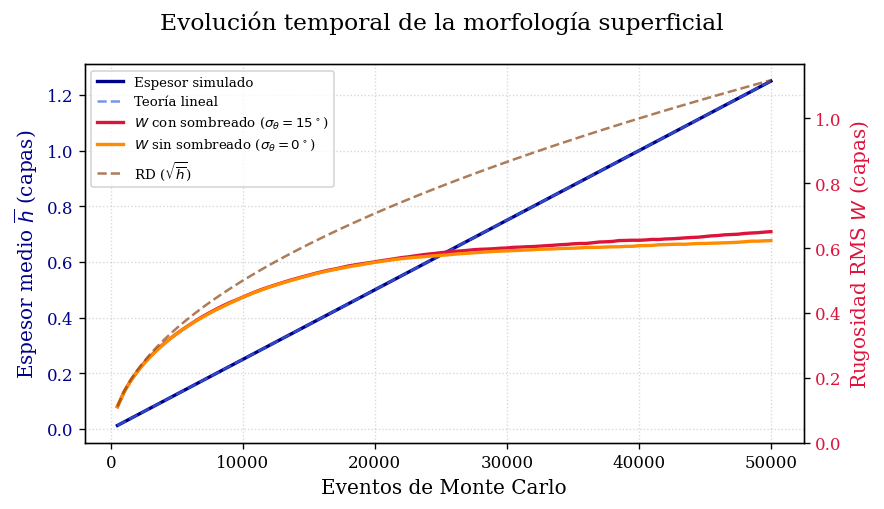

In [17]:
# Evolución temporal con y sin sombreado, frente a la referencia RD
fig, ax1 = plt.subplots(figsize=(7.5, 4.3))

color_esp = "darkblue"
ax1.set_xlabel("Eventos de Monte Carlo")
ax1.set_ylabel(r"Espesor medio $\overline{h}$ (capas)", color=color_esp)
ax1.plot(hist_ev, hist_esp, color=color_esp, linewidth=2, label="Espesor simulado")
ax1.plot(hist_ev, hist_ev / n_celdas, "--", color="royalblue", alpha=0.7, label="Teoría lineal")
ax1.tick_params(axis="y", labelcolor=color_esp)
ax1.grid(True, linestyle=":", alpha=0.5)

# Segundo eje vertical para la rugosidad, cuya escala numérica es distinta.
ax2 = ax1.twinx()
color_rug = "crimson"
ax2.set_ylabel(r"Rugosidad RMS $W$ (capas)", color=color_rug)
ax2.plot(hist_ev, hist_rug, color=color_rug, linewidth=2, label=rf"$W$ con sombreado ($\sigma_\theta = {SIGMA_ANGLE}^\circ$)")
ax2.plot(hist_ev, hist_rug_sin, color="darkorange", linewidth=2, label=r"$W$ sin sombreado ($\sigma_\theta = 0^\circ$)")
ax2.plot(hist_ev, np.sqrt(hist_ev / n_celdas), "--", color="saddlebrown", alpha=0.7, label=r"RD ($\sqrt{\overline{h}}$)")
ax2.set_ylim(bottom=0)
ax2.tick_params(axis="y", labelcolor=color_rug)

fig.suptitle("Evolución temporal de la morfología superficial")
fig.tight_layout()

# Una sola leyenda con las curvas de ambos ejes
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()
ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc="upper left", fontsize=8)
fig.savefig("shadowing_evolucion_temporal.png", bbox_inches="tight")
plt.show()

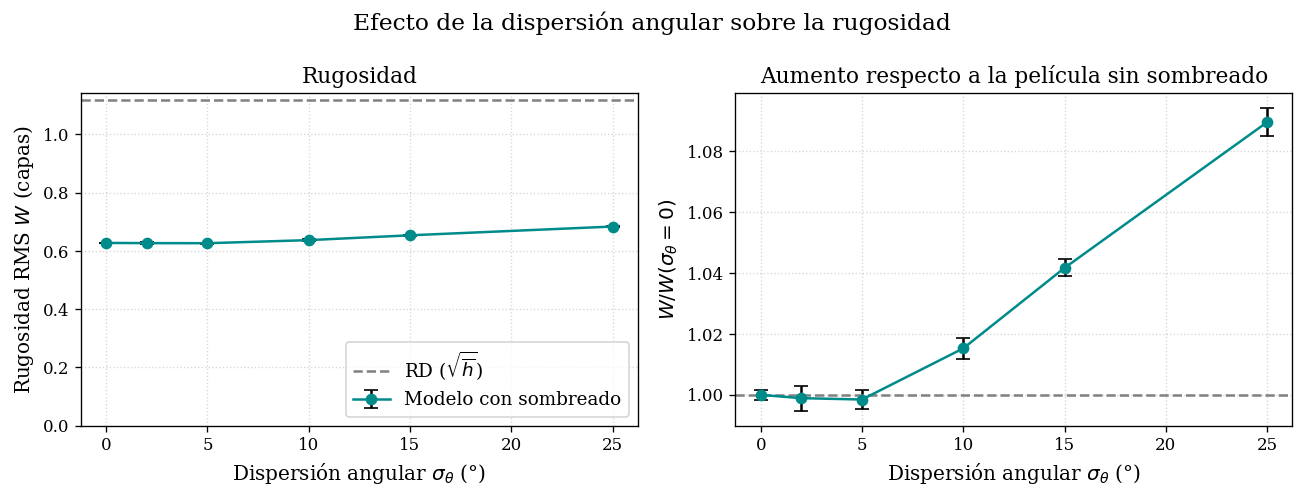

In [18]:
# Rugosidad frente a la dispersión angular: valor absoluto y cociente respecto a sigma = 0
fig, (ax_w, ax_c) = plt.subplots(1, 2, figsize=(11, 4.2))

ax_w.errorbar(
    df_angulos["Sigma (°)"], df_angulos["Rugosidad media (capas)"], yerr=df_angulos["Desv. rugosidad"],
    fmt="o-", color="darkcyan", ecolor="black", capsize=4, lw=1.5, label="Modelo con sombreado",
)
ax_w.axhline(rugosidad_rd, color="gray", linestyle="--", label=r"RD ($\sqrt{\overline{h}}$)")
ax_w.set_ylim(bottom=0)
ax_w.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax_w.set_title("Rugosidad")
ax_w.legend(loc="lower right")

ax_c.errorbar(
    df_angulos["Sigma (°)"], df_angulos["W / W(sigma = 0)"],
    yerr=df_angulos["Desv. rugosidad"] / df_angulos["Rugosidad media (capas)"].iloc[0],
    fmt="o-", color="darkcyan", ecolor="black", capsize=4, lw=1.5,
)
ax_c.axhline(1.0, color="gray", linestyle="--")
ax_c.set_ylabel(r"$W / W(\sigma_\theta = 0)$")
ax_c.set_title("Aumento respecto a la película sin sombreado")

for ax in (ax_w, ax_c):
    ax.set_xlabel(r"Dispersión angular $\sigma_\theta$ (°)")
    ax.grid(True, linestyle=":", alpha=0.5)
fig.suptitle("Efecto de la dispersión angular sobre la rugosidad")
fig.tight_layout()
fig.savefig("shadowing_tendencia_angulo.png", bbox_inches="tight")
plt.show()

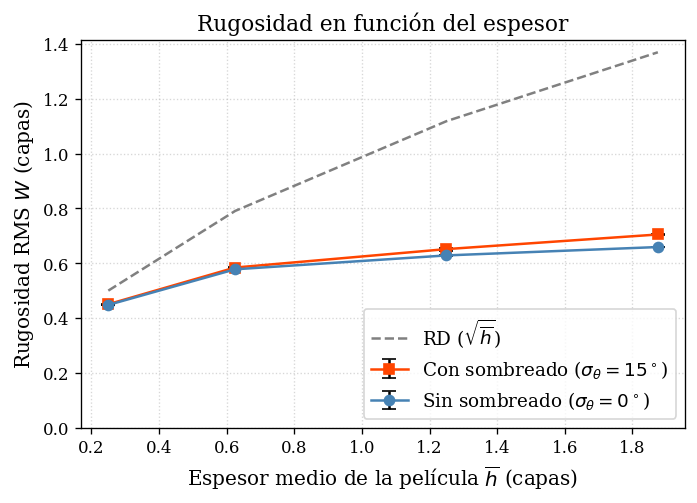

In [19]:
# Rugosidad frente al espesor nominal, con y sin sombreado
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(
    df_espesores["Espesor nominal (capas)"], df_espesores["W con sombreado"],
    yerr=df_espesores["Desv. con sombreado"], fmt="s-", color="orangered", ecolor="black",
    capsize=4, lw=1.5, label=rf"Con sombreado ($\sigma_\theta = {SIGMA_FIJO_ESTUDIO}^\circ$)",
)
ax.errorbar(
    df_espesores["Espesor nominal (capas)"], df_espesores["W sin sombreado"],
    yerr=df_espesores["Desv. sin sombreado"], fmt="o-", color="steelblue", ecolor="black",
    capsize=4, lw=1.5, label=r"Sin sombreado ($\sigma_\theta = 0^\circ$)",
)
ax.plot(
    df_espesores["Espesor nominal (capas)"], df_espesores["W de RD (sqrt(h))"], "--",
    color="gray", label=r"RD ($\sqrt{\overline{h}}$)",
)
ax.set_xlabel(r"Espesor medio de la película $\overline{h}$ (capas)")
ax.set_ylabel(r"Rugosidad RMS $W$ (capas)")
ax.set_ylim(bottom=0)
ax.set_title("Rugosidad en función del espesor")
ax.grid(True, linestyle=":", alpha=0.5)
ax.legend(loc="lower right")
fig.savefig("shadowing_tendencia_espesor.png", bbox_inches="tight")
plt.show()

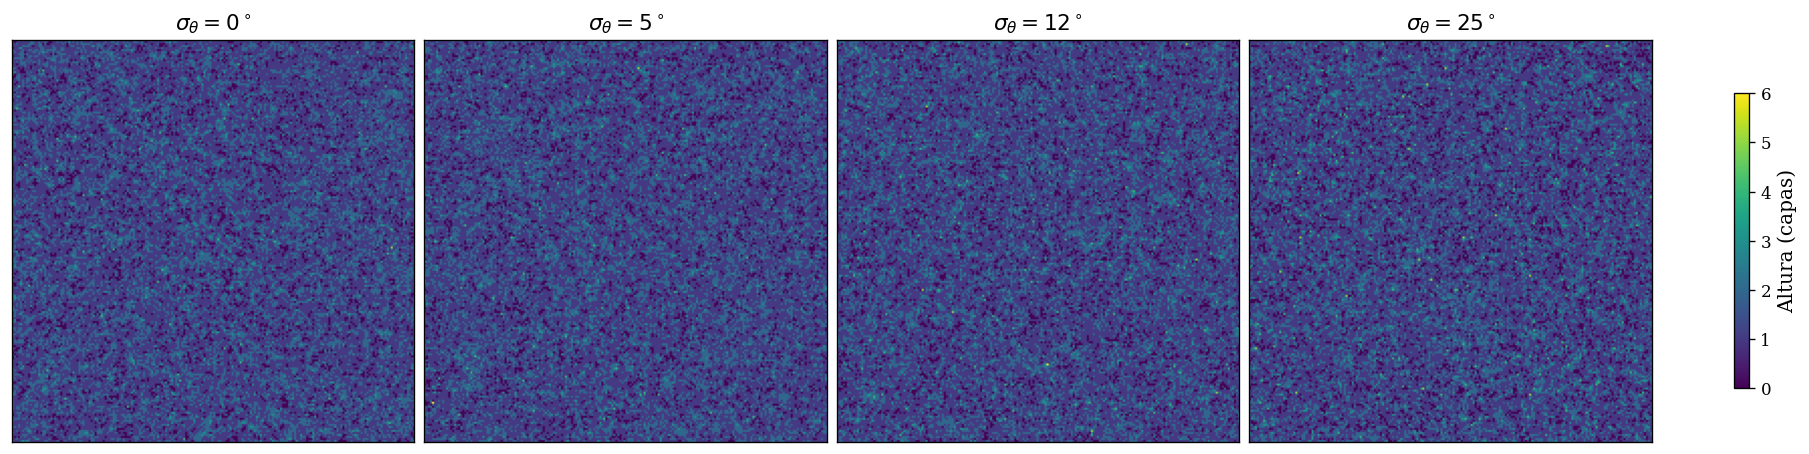

In [20]:
# Mapas topográficos a distintas dispersiones angulares, con una escala de color común
fig, axes = plt.subplots(1, len(ANGULOS_COMPLEMENTARIOS), figsize=(15, 3.8), constrained_layout=True)
vmax_comun = max(int(superficies_comparativas[s].max()) for s in ANGULOS_COMPLEMENTARIOS)

for ax, sigma in zip(axes, ANGULOS_COMPLEMENTARIOS):
    # Se transpone la matriz para que el eje horizontal sea x (primer índice de la malla).
    imagen = ax.imshow(
        superficies_comparativas[sigma].T, origin="lower", cmap="viridis", vmin=0, vmax=vmax_comun
    )
    ax.set_title(rf"$\sigma_\theta = {sigma}^\circ$")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(imagen, ax=axes, shrink=0.7, label="Altura (capas)")
fig.savefig("shadowing_comparativa_2d.png", bbox_inches="tight")
plt.show()

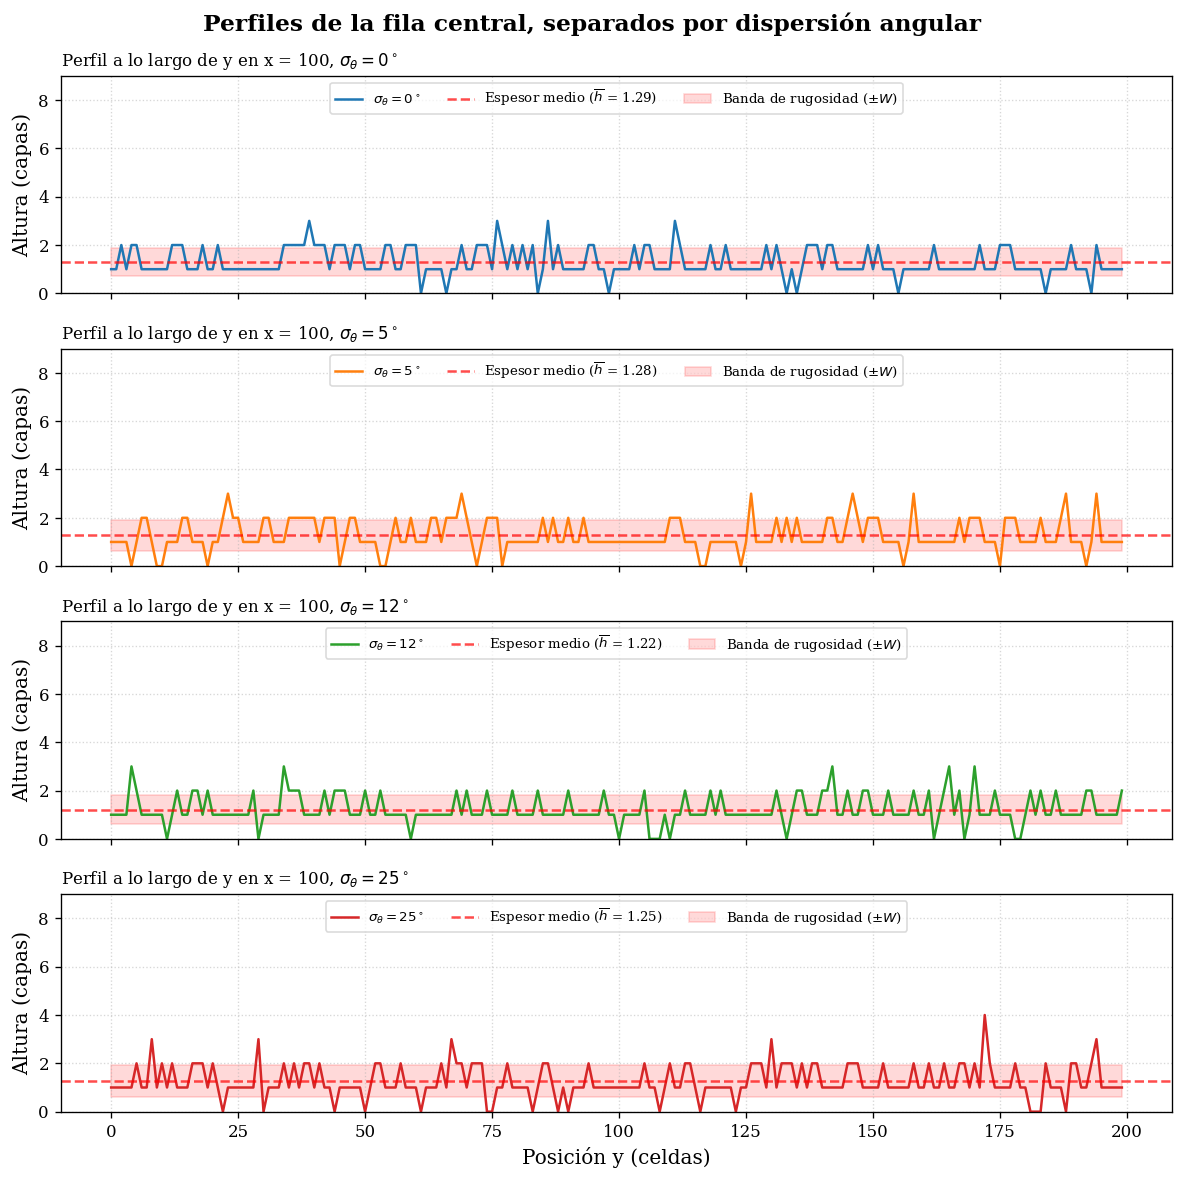

In [21]:
# Perfiles de la fila central, separados por dispersión angular
x_central = NX // 2
colores = plt.cm.tab10.colors
fig, axes = plt.subplots(len(ANGULOS_COMPLEMENTARIOS), 1, figsize=(10, 10), sharex=True, sharey=True)

for ax, sigma, color in zip(axes, ANGULOS_COMPLEMENTARIOS, colores):
    perfil = superficies_comparativas[sigma][x_central, :]
    ax.plot(perfil, lw=1.5, color=color, label=rf"$\sigma_\theta = {sigma}^\circ$")
    ax.axhline(
        perfil.mean(), color="red", linestyle="--", alpha=0.7,
        label=rf"Espesor medio ($\overline{{h}}$ = {perfil.mean():.2f})",
    )
    ax.fill_between(
        range(NY), perfil.mean() - perfil.std(), perfil.mean() + perfil.std(),
        color="red", alpha=0.15, label=r"Banda de rugosidad ($\pm W$)",
    )
    ax.set_title(rf"Perfil a lo largo de y en x = {x_central}, $\sigma_\theta = {sigma}^\circ$", fontsize=10, loc="left")
    ax.set_ylabel("Altura (capas)")
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper center", ncol=3, fontsize=8, framealpha=0.7)

axes[0].set_ylim(0, 1.5 * vmax_comun)
axes[-1].set_xlabel("Posición y (celdas)")
fig.suptitle("Perfiles de la fila central, separados por dispersión angular", fontweight="bold")
fig.tight_layout()
fig.savefig("shadowing_comparativa_perfiles_subplots.png", bbox_inches="tight")
plt.show()

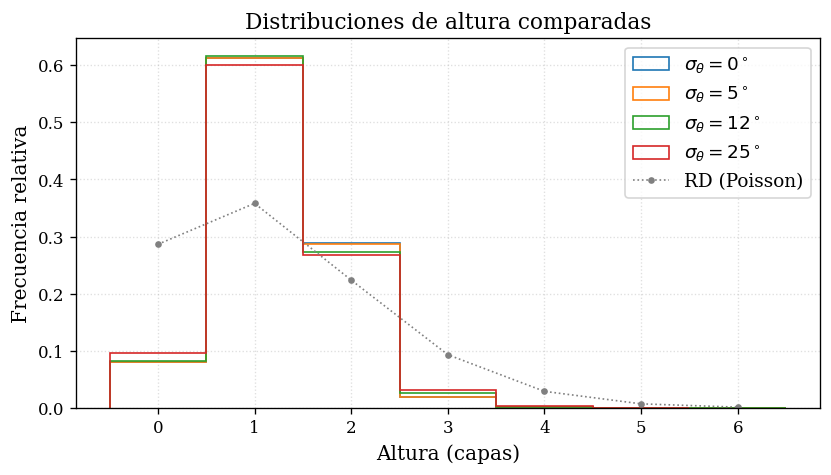

In [22]:
# Distribuciones de alturas a distintas dispersiones angulares
fig, ax = plt.subplots(figsize=(8, 4))
for sigma, color in zip(ANGULOS_COMPLEMENTARIOS, colores):
    superficie = superficies_comparativas[sigma]
    # Un intervalo de anchura unidad por altura entera: con density=True, la altura
    # del escalón es la frecuencia relativa de esa altura.
    ax.hist(
        superficie.ravel(), bins=np.arange(superficie.min(), superficie.max() + 2) - 0.5,
        density=True, histtype="step", lw=1.6, color=color, label=rf"$\sigma_\theta = {sigma}^\circ$",
    )
alturas_rd = np.arange(0, max(int(s.max()) for s in superficies_comparativas.values()) + 1)
ax.plot(
    alturas_rd, poisson.pmf(alturas_rd, espesor_teo), "o:", color="gray",
    markersize=3, linewidth=1.0, label="RD (Poisson)",
)
ax.set_xlabel("Altura (capas)")
ax.set_ylabel("Frecuencia relativa")
ax.set_title("Distribuciones de altura comparadas")
ax.grid(True, linestyle=":", alpha=0.4)
ax.legend()
fig.savefig("shadowing_comparativa_histogramas.png", bbox_inches="tight")
plt.show()

## 9. Análisis de resultados

### 9.1 Condición base

La condición base ($\sigma_\theta = 15^\circ$, $T = 400$ K) deposita un espesor medio de 1.25 capas, exacto por conservación de partículas. Su rugosidad, de unas 0.65 capas, es poco más de la mitad de la de RD ($\sqrt{1.25} = 1.12$) y solo un 4 % mayor que la de la misma película sin sombreado. Alrededor del 8 % de las celdas permanece sin cubrir, tanto con sombreado como sin él. Por tanto, los valles de altura cero de la película no se deben al sombreado, sino a la baja cobertura: a 1.25 capas la película todavía no cubre todo el sustrato. La salida de la sección 6 informa las cifras de la realización ejecutada.

### 9.2 Sombreado sin difusión

Sin difusión ($T = 0$ K), la rugosidad a $\sigma_\theta = 0$ coincide con la de RD, lo que valida el código frente a una predicción analítica. Con dispersión angular, en cambio, la rugosidad supera a RD y lo hace más cuanto mayor es $\sigma_\theta$: cerca de un 25 % con $\sigma_\theta = 15^\circ$ y más de un 50 % con $\sigma_\theta = 25^\circ$. La fracción de celdas sin cubrir también aumenta respecto a RD. Este es el efecto del sombreado sin la compensación de la difusión: los rayos oblicuos que sobrevuelan una elevación chocan con ella y no llegan al valle contiguo, con lo que la elevación crece a costa del valle.

### 9.3 Sombreado con difusión

A $T = 400$ K el efecto es mucho menor. La rugosidad aumenta de forma monótona con $\sigma_\theta$, pero solo un 4 % con $15^\circ$ y entre un 9 y un 10 % con $25^\circ$ respecto a $\sigma_\theta = 0$, como muestra el cociente de la tabla del experimento I. La difusión por descenso lleva a las partículas que chocan con una elevación hacia sus vecinos más bajos, con lo que compensa buena parte del sombreado. La altura máxima crece ligeramente con $\sigma_\theta$ y la fracción de celdas vacías pasa de aproximadamente el 8 % a poco más del 9 %, lejos del valor de RD.

### 9.4 Dependencia con el espesor

La rugosidad crece con el espesor tanto con sombreado como sin él, pero cada vez más despacio. En la evolución temporal, el exponente de crecimiento efectivo de la sección 6 es del orden de 0.2 en ambos casos, muy inferior al valor $1/2$ de RD, de modo que no hay crecimiento acelerado en este intervalo. El cociente entre la rugosidad con y sin sombreado aumenta con el espesor, de valores cercanos a 1 con 0.25 capas a cerca de 1.07 con 1.9 capas (tabla del experimento II). Es lo esperado de una realimentación positiva, que necesita relieve previo para actuar. En el modelo de Karunasiri et al. (1989), con difusión suficiente la película es compacta hasta una altura crítica y se rugosa después; las 2 capas aquí simuladas son una película demasiado delgada para explorar ese régimen.

### 9.5 Firmas morfológicas

Los mapas, los perfiles y los histogramas a distintas dispersiones angulares son muy parecidos entre sí. La distribución de alturas es más estrecha que la de Poisson de RD a todas las dispersiones, y con $\sigma_\theta$ grande aparece una cola algo más larga hacia alturas mayores. No se observan columnas ni islas aisladas.

### 9.6 Alcance del modelo

El modelo usa la aproximación SOS, en la que una partícula que choca con la pared lateral de una columna se incorpora arriba de ella; por eso no puede representar el ensanchamiento de las columnas ni la porosidad. La distribución normal de los ángulos no está acotada y el paso vertical de 0.5 capas puede omitir columnas delgadas cuando $|\tan\theta| > 2$. Las distancias laterales y verticales comparten la unidad de celda. Las condiciones periódicas representan una sección de un sustrato extenso con flujo uniforme. Por estas razones los resultados describen tendencias cualitativas y no la morfología de una película real de cobre.

## 10. Conclusiones

* Se implementó un trazador de rayos de línea de visión con condiciones de frontera periódicas, acoplado a la relajación térmica por descenso. Sin difusión, el modelo con $\sigma_\theta = 0$ reproduce la rugosidad de RD y con $\sigma_\theta > 0$ la supera, lo que valida el mecanismo de sombreado.

* A $T = 400$ K y 1.25 capas de espesor, la difusión compensa la mayor parte del sombreado: la rugosidad aumenta un 4 % con $\sigma_\theta = 15^\circ$ y entre un 9 y un 10 % con $25^\circ$ respecto a la película sin sombreado. El efecto crece con el espesor, y el crecimiento de $W$ es más lento que el de RD, sin señales de aceleración ni de columnas en el intervalo simulado.

* El modelo, basado en una función de altura, no representa el ensanchamiento de las columnas ni la porosidad, y películas más gruesas o ángulos mayores requerirían un estudio específico. Los cuadernos siguientes de la serie incorporan mecanismos adicionales sobre esta base.

## 11. Referencias

**Fuentes académicas primarias**

* Barabási, A.-L., & Stanley, H. E. (1995). *Fractal concepts in surface growth*. Cambridge University Press.

* Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E., Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M., Haldane, A., del Río, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2

* Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

* Karunasiri, R. P. U., Bruinsma, R., & Rudnick, J. (1989). Thin-film growth and the shadow instability. *Physical Review Letters, 62*(7), 788–791. https://doi.org/10.1103/PhysRevLett.62.788

* Lam, S. K., Pitrou, A., & Seibert, S. (2015). Numba: A LLVM-based Python JIT compiler. En *Proceedings of the Second Workshop on the LLVM Compiler Infrastructure in HPC* (LLVM '15) (Artículo 7, pp. 1–6). Association for Computing Machinery. https://doi.org/10.1145/2833157.2833162

* McKinney, W. (2010). Data structures for statistical computing in Python. En S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56–61). https://doi.org/10.25080/Majora-92bf1922-00a

* Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., Burovski, E., Peterson, P., Weckesser, W., Bright, J., van der Walt, S. J., Brett, M., Wilson, J., Millman, K. J., Mayorov, N., Nelson, A. R. J., Jones, E., Kern, R., Larson, E., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2

**Recursos complementarios**

* Numba. (s. f.). *Supported NumPy features*. Numba documentation. https://numba.pydata.org/numba-doc/latest/reference/numpysupported.html